**Import Data and Required Packages**

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn

In [16]:
# read the data
df = pd.read_csv("data/student_placement.csv")
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


**Preparing X and Y variables**

In [17]:
X = df.drop(columns=['placement_status', 'salary_package_lpa'])
y = df['placement_status']

In [18]:
X.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1


In [19]:
print(f"categories in branch: {X['branch'].unique()}")
print()
print(f"categories in college_tier: {X['college_tier'].unique()}")

categories in branch: ['ECE' 'Chemical' 'EE' 'CE' 'CSE' 'IT' 'ME']

categories in college_tier: ['Tier-3' 'Tier-2' 'Tier-1']


In [20]:
# perform train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Shape : {X_train.shape}")
print(f"Testing Shape : {X_test.shape}")

Training Shape : (80000, 16)
Testing Shape : (20000, 16)


- The branch column is a nominal categorical feature, so One Hot Encoding is used to convert categories into numerical form without introducing ordinal relationships.
- The college_tier column is an ordinal categorical feature, so Ordinal Encoding is applied to preserve the ranking order among tiers.
- Numerical features contain multiple outliers, therefore RobustScaler is used for feature scaling since it is less sensitive to outliers compared to StandardScaler.

To implement these preprocessing steps efficiently, a ColumnTransformer named preprocessor is created.
A Pipeline is then defined by combining:

1. The preprocessor
2. The selected machine learning algorithm

In [21]:
numerical_features = X.select_dtypes(exclude='object').columns
print(f"Numerical features: {numerical_features}")

Numerical features: Index(['cgpa', 'backlogs', 'coding_skills', 'dsa_score', 'aptitude_score',
       'communication_skills', 'ml_knowledge', 'system_design', 'internships',
       'projects_count', 'certifications', 'hackathons',
       'open_source_contributions', 'extracurriculars'],
      dtype='object')


In [22]:
# define the transformer for the numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('one_hot_encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['branch']),
        ('ordinal_encoder', OrdinalEncoder(categories=[['Tier-1', 'Tier-2', 'Tier-3']], unknown_value=-1, handle_unknown='use_encoded_value'), ['college_tier']),
        ('scaler', RobustScaler(), numerical_features)
    ], remainder='passthrough'
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('one_hot_encoder', ...), ('ordinal_encoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer

In [23]:
# create an utility function to evaluate the model performance
def evaluate_model(y_true, y_pred, y_prob):
    """Evaluate the performance of machine learning model"""
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc_score': auc_score
    }

**Logistic Regression**

In [25]:
# connect to remote server
mlflow.set_tracking_uri("http://127.0.0.1:5000")

# experiment name
mlflow.set_experiment("Placement Predictor")

with mlflow.start_run(run_name='Logistic Regression'):
    # define the logistic regression model
    log_reg_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression())
    ])

    # fit the data into the model
    log_reg_pipeline.fit(X_train, y_train)

    # make predictions
    y_pred1 = log_reg_pipeline.predict(X_test)
    y_prob1 = log_reg_pipeline.predict_proba(X_test)[:, 1]

    # evaluate the model
    metrics = evaluate_model(y_test, y_pred1, y_prob1)

    # log parameters
    mlflow.log_param("model", "LogisticRegression")

    # log metrics
    mlflow.log_metrics(metrics)

    # log the model
    mlflow.sklearn.log_model(
        log_reg_pipeline,
        'logistic_regression_pipeline'
    )

2026/05/12 22:41:32 INFO mlflow.tracking.fluent: Experiment with name 'Placement Predictor' does not exist. Creating a new experiment.
2026/05/12 22:41:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 22:41:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Logistic Regression at: http://127.0.0.1:5000/#/experiments/1/runs/0fdeab052bc840699a013a6bedcca66d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [ ]:
# perform hyperparameter tuning for logistic regression

# define the parameter grid
param_grid1 = [
    {
        'classifier__l1_ratio': [0, 0.5, 0.7, 0.9, 1],
        'classifier__solver': ['saga'],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__class_weight': ['balanced', {0: 1.5, 1:1}, {0:2, 1:1}, {0:1.25, 1:1}],
        'classifier__max_iter': [100, 500, 1000]
    }
]

param_grid2 = [
    {
        'classifier__l1_ratio': [0, 1],
        'classifier__solver': ['liblinear', 'lbfgs'],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__class_weight': ['balanced', {0: 1.5, 1:1}, {0:2, 1:1}, {0:1.25, 1:1}],
        'classifier__max_iter': [100, 500, 1000]
    }
]

random_search = RandomizedSearchCV(log_reg_pipeline, param_distributions=param_grid2, n_iter=30, cv=3, scoring='roc_auc', random_state=42)

mlflow.set_tracking_uri("http://127.0.0.1:5000")

mlflow.set_experiment("Placement Predictor")

with mlflow.start_run(run_name="Logistic Regression Hyperparameter Tuning"):

    # fit randomized search
    random_search.fit(X_train, y_train)

    # best model
    best_model = random_search.best_estimator_

    # predictions
    y_pred = best_model.predict(X_test)

    y_prob = best_model.predict_proba(X_test)[:, 1]

    # evaluate
    metrics = evaluate_model(
        y_test,
        y_pred,
        y_prob
    )

    # log best parameters
    mlflow.log_params(random_search.best_params_)

    # log best score from CV
    mlflow.log_metric(
        "best_cv_score",
        random_search.best_score_
    )

    # log test metrics
    mlflow.log_metrics(metrics)

    # log model
    mlflow.sklearn.log_model(
        best_model,
        "best_logistic_regression_pipeline"
    )

print("Best Hyperparameters:", random_search.best_params_)
print("Best ROC AUC Score:", random_search.best_score_)

2026/05/12 22:58:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 22:58:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Logistic Regression Hyperparameter Tuning at: http://127.0.0.1:5000/#/experiments/1/runs/bf1b86619eb74746a81cf31908cbfece
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Best Hyperparameters: {'classifier__solver': 'saga', 'classifier__max_iter': 1000, 'classifier__l1_ratio': 0.5, 'classifier__class_weight': 'balanced', 'classifier__C': 10}
Best ROC AUC Score: 0.685647171121948


Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.60      0.52      6305
           1       0.78      0.66      0.72     13695

    accuracy                           0.64     20000
   macro avg       0.62      0.63      0.62     20000
weighted avg       0.68      0.64      0.66     20000


ROC AUC Score: 0.6855829865493261

Confusion Matrix:


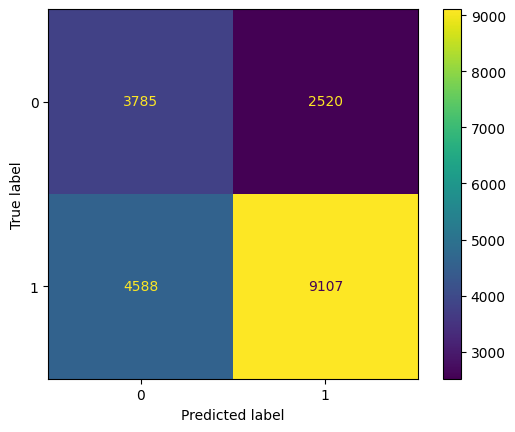

In [12]:
best_log_reg_pipeline = random_search.best_estimator_
y_pred6 = best_log_reg_pipeline.predict(X_test)
y_prob6 = best_log_reg_pipeline.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred6, y_prob6)

**KNN**

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.28      0.33      6305
           1       0.71      0.82      0.76     13695

    accuracy                           0.64     20000
   macro avg       0.56      0.55      0.54     20000
weighted avg       0.61      0.64      0.62     20000


ROC AUC Score: 0.5811298079637416

Confusion Matrix:


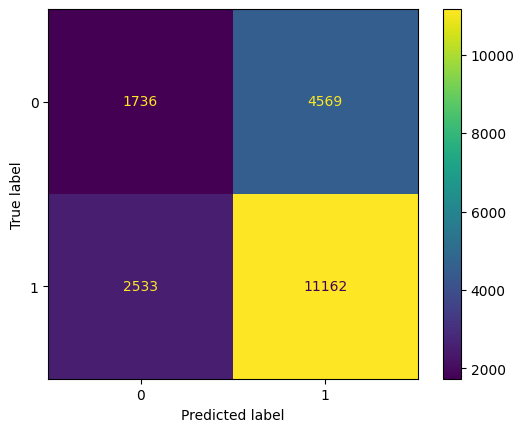

In [13]:
# define the knn model
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# fit the data into the model
knn_pipeline.fit(X_train, y_train)

# make predictions
y_pred2 = knn_pipeline.predict(X_test)
y_prob2 = knn_pipeline.predict_proba(X_test)[:, 1]

# evaluate the model
evaluate_model(y_test, y_pred2, y_prob2)

In [14]:
# perform hyperparameter tuning for KNN
param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski']
}

# fit the random search model
random_search_knn = RandomizedSearchCV(knn_pipeline, param_distributions=param_grid, n_iter=20, cv=3, scoring='roc_auc', random_state=42)
random_search_knn.fit(X_train, y_train)

print("Best Hyperparameters for KNN:", random_search_knn.best_params_)
print("Best ROC AUC Score for KNN:", random_search_knn.best_score_)

Best Hyperparameters for KNN: {'classifier__weights': 'distance', 'classifier__n_neighbors': 9, 'classifier__metric': 'minkowski'}
Best ROC AUC Score for KNN: 0.6072256090963286


Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.23      0.30      6305
           1       0.71      0.86      0.78     13695

    accuracy                           0.66     20000
   macro avg       0.57      0.55      0.54     20000
weighted avg       0.62      0.66      0.63     20000


ROC AUC Score: 0.6057976727036471

Confusion Matrix:


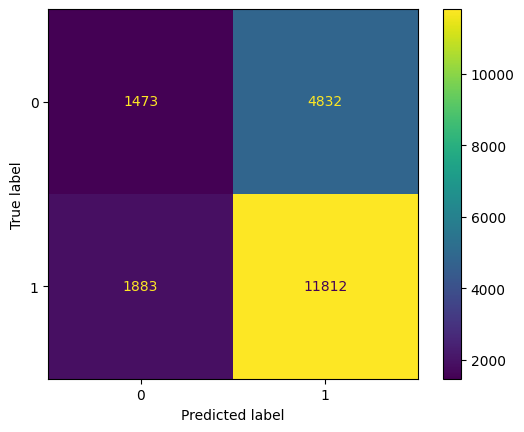

In [15]:
# evaluate the best KNN model
best_knn_pipeline = random_search_knn.best_estimator_
y_pred7 = best_knn_pipeline.predict(X_test)
y_prob7 = best_knn_pipeline.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred7, y_prob7)

**SVC**

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.17      0.26      6305
           1       0.71      0.94      0.81     13695

    accuracy                           0.70     20000
   macro avg       0.65      0.56      0.54     20000
weighted avg       0.67      0.70      0.64     20000


ROC AUC Score: 0.6855390128027068

Confusion Matrix:


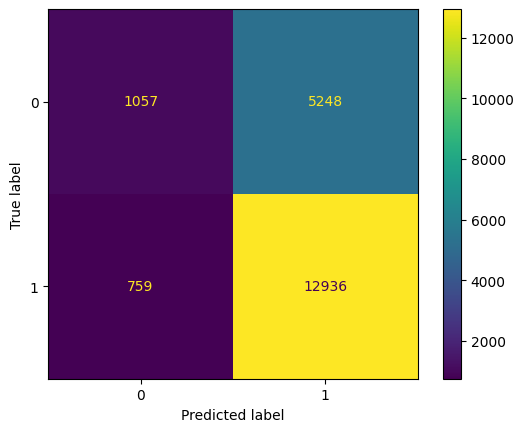

In [16]:
# define the svc model
svc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC())
])

# fit the data into the model
svc_pipeline.fit(X_train, y_train)

# make predictions
y_pred3 = svc_pipeline.predict(X_test)
y_prob3 = svc_pipeline.decision_function(X_test)

# evaluate the model
evaluate_model(y_test, y_pred3, y_prob3)

In [17]:
# perform hyperparameter tuning for linear svc
param_grid = [

    {
        'classifier__penalty': ['l1'],
        'classifier__loss': ['squared_hinge'],
        'classifier__C': [0.1, 0.5, 1, 10],
        'classifier__class_weight': [
            'balanced',
            {0:1.5, 1:1},
            {0:2, 1:1}
        ],
        'classifier__max_iter': [10000, 5000, 1000]
    },

    {
        'classifier__penalty': ['l2'],
        'classifier__loss': ['hinge', 'squared_hinge'],
        'classifier__C': [0.1, 0.5, 1, 10],
        'classifier__class_weight': [
            'balanced',
            {0:1.5, 1:1},
            {0:2, 1:1}
        ],
        'classifier__max_iter': [10000, 5000, 1000]
    }
]

random_search_svc = RandomizedSearchCV(svc_pipeline, param_distributions=param_grid, n_iter=30, cv=3, scoring='roc_auc', random_state=42)
random_search_svc.fit(X_train, y_train)
    
print("Best Hyperparameters for SVC:", random_search_svc.best_params_)
print("Best ROC AUC Score for SVC:", random_search_svc.best_score_)

d:\AI_Projects\Placement Predictor\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\AI_Projects\Placement Predictor\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\AI_Projects\Placement Predictor\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\AI_Projects\Placement Predictor\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\AI_Projects\Placement Predictor\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\AI_Projects\Placement Predictor\venv\Lib\site-packages\sklearn

Best Hyperparameters for SVC: {'classifier__penalty': 'l2', 'classifier__max_iter': 5000, 'classifier__loss': 'hinge', 'classifier__class_weight': {0: 2, 1: 1}, 'classifier__C': 0.5}
Best ROC AUC Score for SVC: 0.6856459326727954


d:\AI_Projects\Placement Predictor\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.62      0.52      6305
           1       0.79      0.65      0.71     13695

    accuracy                           0.64     20000
   macro avg       0.62      0.63      0.62     20000
weighted avg       0.68      0.64      0.65     20000


ROC AUC Score: 0.6856193051348932

Confusion Matrix:


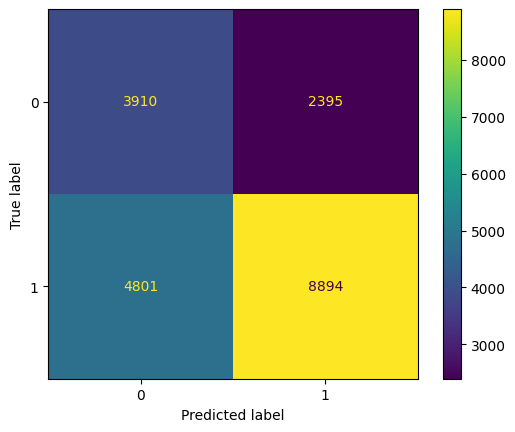

In [18]:
# evaluate the best linear svc model
best_svc_pipeline = random_search_svc.best_estimator_
y_pred8 = best_svc_pipeline.predict(X_test)
y_prob8 = best_svc_pipeline.decision_function(X_test)

evaluate_model(y_test, y_pred8, y_prob8)

**Random Forest**

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.18      0.27      6305
           1       0.71      0.93      0.80     13695

    accuracy                           0.69     20000
   macro avg       0.62      0.55      0.54     20000
weighted avg       0.66      0.69      0.64     20000


ROC AUC Score: 0.6634154931310565

Confusion Matrix:


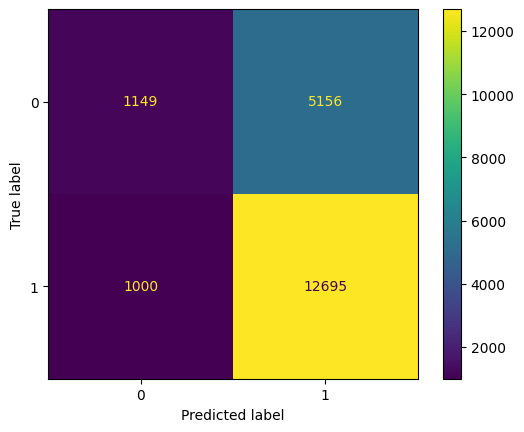

In [19]:
# define the random forest model
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_jobs=-1))
])

# fit the data into the model
rf_pipeline.fit(X_train, y_train)

# make predictions
y_pred4 = rf_pipeline.predict(X_test)
y_prob4 = rf_pipeline.predict_proba(X_test)[:, 1]

# evaluate the model
evaluate_model(y_test, y_pred4, y_prob4)

In [20]:
# perform hyperparameter tuning for random forest
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 10, 15],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [3, 5, 10, 20],
    'classifier__class_weight': ['balanced', {0: 1.5, 1:1}, {0:2, 1:1}, {0:1.25, 1:1}]
}

random_search_rf = RandomizedSearchCV(rf_pipeline, param_distributions=param_grid, n_iter=30, cv=3, scoring='roc_auc', random_state=42)
random_search_rf.fit(X_train, y_train)

print("Best Hyperparameters for Random Forest:", random_search_rf.best_params_)
print("Best ROC AUC Score for Random Forest:", random_search_rf.best_score_)

Best Hyperparameters for Random Forest: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 20, 'classifier__max_depth': 15, 'classifier__class_weight': {0: 1.5, 1: 1}}
Best ROC AUC Score for Random Forest: 0.677510193462109


Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.33      0.40      6305
           1       0.74      0.85      0.79     13695

    accuracy                           0.69     20000
   macro avg       0.62      0.59      0.60     20000
weighted avg       0.67      0.69      0.67     20000


ROC AUC Score: 0.6792397070076861

Confusion Matrix:


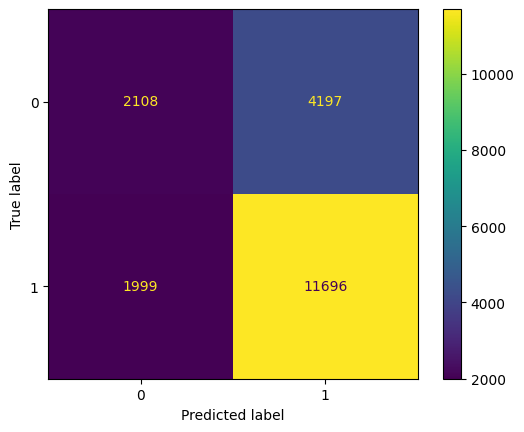

In [21]:
# evaluate the best random forest model
best_rf_pipeline = random_search_rf.best_estimator_
y_pred9 = best_rf_pipeline.predict(X_test)
y_prob9 = best_rf_pipeline.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred9, y_prob9)

**XGBoost**

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.23      0.32      6305
           1       0.72      0.90      0.80     13695

    accuracy                           0.69     20000
   macro avg       0.62      0.56      0.56     20000
weighted avg       0.65      0.69      0.65     20000


ROC AUC Score: 0.6637114444368202

Confusion Matrix:


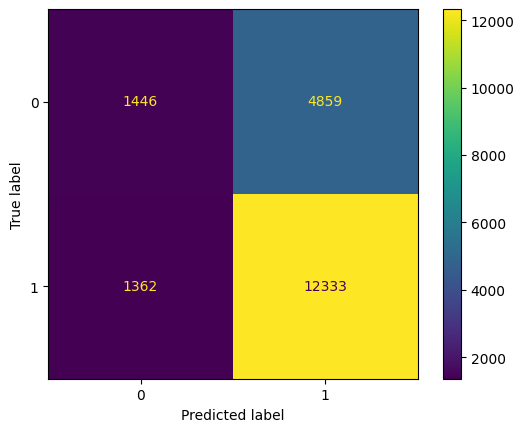

In [22]:
# define the xgboost model
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_jobs=-1))
])

# fit the data into the model
xgb_pipeline.fit(X_train, y_train)

# make predictions
y_pred5 = xgb_pipeline.predict(X_test)
y_prob5 = xgb_pipeline.predict_proba(X_test)[:, 1]

# evaluate the model
evaluate_model(y_test, y_pred5, y_prob5)

In [23]:
# perform hyperparameter tuning for xgboost
param_grid = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [3, 5, 10, 15],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__gamma': [0, 0.1, 0.2],
    'classifier__reg_alpha': [0, 0.5, 1, 10],
    'classifier__reg_lambda': [0, 0.5, 1, 5],
    'classifier__n_jobs': [-1]
}

random_search_xgb = RandomizedSearchCV(xgb_pipeline, param_distributions=param_grid, n_iter=30, cv=3, scoring='roc_auc', random_state=42)
random_search_xgb.fit(X_train, y_train)

print("Best Hyperparameters for XGBoost:", random_search_xgb.best_params_)
print("Best ROC AUC Score for XGBoost:", random_search_xgb.best_score_)

Best Hyperparameters for XGBoost: {'classifier__subsample': 1.0, 'classifier__reg_lambda': 1, 'classifier__reg_alpha': 10, 'classifier__n_jobs': -1, 'classifier__n_estimators': 200, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.1, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.6}
Best ROC AUC Score for XGBoost: 0.6825406106081927


Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.19      0.28      6305
           1       0.71      0.93      0.81     13695

    accuracy                           0.70     20000
   macro avg       0.64      0.56      0.55     20000
weighted avg       0.67      0.70      0.64     20000


ROC AUC Score: 0.6830094337410199

Confusion Matrix:


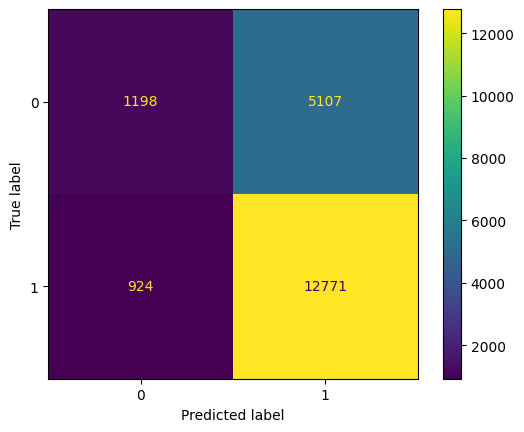

In [24]:
# evaluate the best xgboost model
best_xgb_pipeline = random_search_xgb.best_estimator_
y_pred10 = best_xgb_pipeline.predict(X_test)
y_prob10 = best_xgb_pipeline.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred10, y_prob10)

Multiple machine learning algorithms including Logistic Regression, LinearSVC, Random Forest, KNN, and XGBoost were implemented and fine-tuned using RandomizedSearchCV. Logistic Regression outperformed the other models and achieved the highest ROC-AUC score of 0.68, making it the best-performing model for placement prediction.